# Spotify Hit Song Prediction

**Statistical Learning Methods [223491-D] — Spring 2025/26**

**Group members:** Imad Eddine Djehlane \ Hyeonji Jo

---

# Introduction

Every year thousands of songs are released, but only a handful ever make it onto the Billboard Hot-100. Spotify computes a set of audio features for every track — things like how danceable it is, how energetic, how loud, and how “happy” it sounds.

The idea of this project is simple:  
**Can we use these audio features to predict whether a song becomes a chart hit?**

This is a **binary classification** problem:

- `target = 1` → the song appeared on the Billboard Hot-100 at some point (**Hit**)
- `target = 0` → the song never charted (**Flop**)

**Dataset:** Spotify Hit Predictor Dataset (1960–2019)  ~41,000 songs across 6 decades, with audio features retrieved from Spotify’s Web API.

# 0. Imports

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, f1_score
)

plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('Ready.')

Ready.


---

# 1. Data Loading & Description

In [3]:
import os
print(os.getcwd())

os.chdir(r"C:\Users\Jarek\OneDrive\Pulpit\archive(1)")


C:\Users\Jarek\OneDrive\Pulpit


In [4]:
# The dataset comes split by decade — we load all 6 files and combine them
decade_map = {
    'dataset-of-60s.csv': 1960,
    'dataset-of-70s.csv': 1970,
    'dataset-of-80s.csv': 1980,
    'dataset-of-90s.csv': 1990,
    'dataset-of-00s.csv': 2000,
    'dataset-of-10s.csv': 2010,
}

frames = []
for fname, decade in decade_map.items():
    tmp = pd.read_csv(fname)
    tmp['decade'] = decade
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
print(f'Total records: {len(df):,}')
print(f'Columns: {list(df.columns)}')

Total records: 41,106
Columns: ['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target', 'decade']


In [5]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,decade
0,Jealous Kind Of Fella,Garland Green,spotify:track:1dtKN6wwlolkM8XZy2y9C1,0.417,0.620,3,-7.727,1,0.0403,0.490,0.000000,0.0779,0.845,185.655,173533,3,32.94975,9,1,1960
1,Initials B.B.,Serge Gainsbourg,spotify:track:5hjsmSnUefdUqzsDogisiX,0.498,0.505,3,-12.475,1,0.0337,0.018,0.107000,0.1760,0.797,101.801,213613,4,48.82510,10,0,1960
2,Melody Twist,Lord Melody,spotify:track:6uk8tI6pwxxdVTNlNOJeJh,0.657,0.649,5,-13.392,1,0.0380,0.846,0.000004,0.1190,0.908,115.940,223960,4,37.22663,12,0,1960
3,Mi Bomba Sonó,Celia Cruz,spotify:track:7aNjMJ05FvUXACPWZ7yJmv,0.590,0.545,7,-12.058,0,0.1040,0.706,0.024600,0.0610,0.967,105.592,157907,4,24.75484,8,0,1960
4,Uravu Solla,P. Susheela,spotify:track:1rQ0clvgkzWr001POOPJWx,0.515,0.765,11,-3.515,0,0.1240,0.857,0.000872,0.2130,0.906,114.617,245600,4,21.79874,14,0,1960


In [6]:
df.describe().round(3)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,decade
count,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.0,41106.000
mean,0.540,0.580,5.214,-10.222,0.693,0.073,0.364,0.154,0.202,0.542,119.338,234877.550,3.894,40.106,10.476,0.5,1982.775
std,0.178,0.253,3.535,5.312,0.461,0.086,0.339,0.304,0.173,0.267,29.099,118967.398,0.423,19.006,4.872,0.5,17.491
min,0.000,0.000,0.000,-49.253,0.000,0.000,0.000,0.000,0.013,0.000,0.000,15168.000,0.000,0.000,0.000,0.0,1960.000
25%,0.420,0.396,2.000,-12.816,0.000,0.034,0.039,0.000,0.094,0.330,97.397,172927.750,4.000,27.600,8.000,0.0,1970.000
50%,0.552,0.601,5.000,-9.257,1.000,0.043,0.258,0.000,0.132,0.558,117.565,217907.000,4.000,35.851,10.000,0.5,1980.000
75%,0.669,0.787,8.000,-6.374,1.000,0.070,0.676,0.061,0.261,0.768,136.494,266773.000,4.000,47.626,12.000,1.0,2000.000
max,0.988,1.000,11.000,3.744,1.000,0.960,0.996,1.000,0.999,0.996,241.423,4170227.000,5.000,433.182,169.000,1.0,2010.000


**Feature descriptions:**


| Feature | Range | Description |
|---|---|---|
| `danceability` | 0–1 | How suitable a song is for dancing |
| `energy` | 0–1 | Intensity and activity level |
| `key` | 0–11 | Musical key |
| `loudness` | dB | Overall loudness of the track |
| `mode` | 0 or 1 | Minor (0) or Major (1) |
| `speechiness` | 0–1 | Presence of spoken words |
| `acousticness` | 0–1 | Probability that the song is acoustic |
| `instrumentalness` | 0–1 | Likelihood of having no vocals |
| `liveness` | 0–1 | Presence of live audience sound |
| `valence` | 0–1 | Musical positivity (happy vs sad) |
| `tempo` | BPM | Estimated song tempo |
| `duration_ms` | ms | Song length |
| `time_signature` | 3–7 | Beats per bar |
| `chorus_hit` | seconds | Approximate chorus start time |
| `sections` | int | Number of song sections |

---

## 2. Data Cleaning & Preprocessing

In [7]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
decade              0
dtype: int64


In [8]:
# Drop text/metadata columns — not useful as model features
df.drop(columns=['track', 'artist', 'uri'], inplace=True)

# The dataset has some songs that appear in multiple decade files (re-releases).
# We already dropped 'uri' but let's remove duplicates based on remaining features.
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows → {len(df):,} remaining')

Removed 330 duplicate rows → 40,776 remaining


In [9]:
# Convert duration from milliseconds to minutes — more intuitive
df['duration_min'] = df['duration_ms'] / 60000
df.drop(columns=['duration_ms'], inplace=True)
print('Converted duration_ms → duration_min')

Converted duration_ms → duration_min


In [10]:
# Remove obvious outliers — very long songs, silence (tempo = 0), etc.
# Using Z-score: remove rows where any numeric feature is more than 4 std devs from the mean
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['target', 'decade', 'key', 'mode', 'time_signature']]

z_scores = np.abs(stats.zscore(df[numeric_cols]))
before = len(df)
df = df[(z_scores < 4).all(axis=1)].reset_index(drop=True)
print(f'Removed {before - len(df)} outlier rows → {len(df):,} remaining')

Removed 1645 outlier rows → 39,131 remaining


In [11]:
# Check class balance after cleaning
print('Target distribution after cleaning:')
print(df['target'].value_counts())
print(f"Hit rate: {df['target'].mean():.1%}")

Target distribution after cleaning:
1    20056
0    19075
Name: target, dtype: int64
Hit rate: 51.3%


In [12]:
# Train / test split (stratified to preserve class balance)
FEATURES = [c for c in df.columns if c != 'target']
X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Scaled version for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 31,304 | Test: 7,827


---

## 3. Exploratory Data Analysis (EDA)

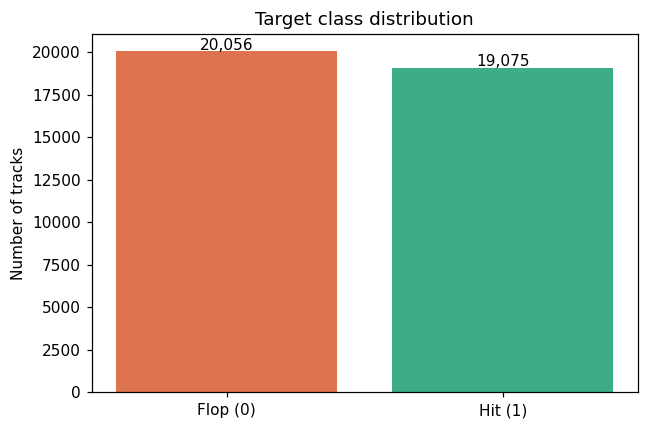

The dataset is perfectly balanced — equal hits and flops.


In [13]:
# --- 3.1 Class distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
ax.bar(['Flop (0)', 'Hit (1)'], counts.values, color=['#d85a30', '#1d9e75'], alpha=0.85)
ax.set_title('Target class distribution')
ax.set_ylabel('Number of tracks')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()
print('The dataset is perfectly balanced — equal hits and flops.')

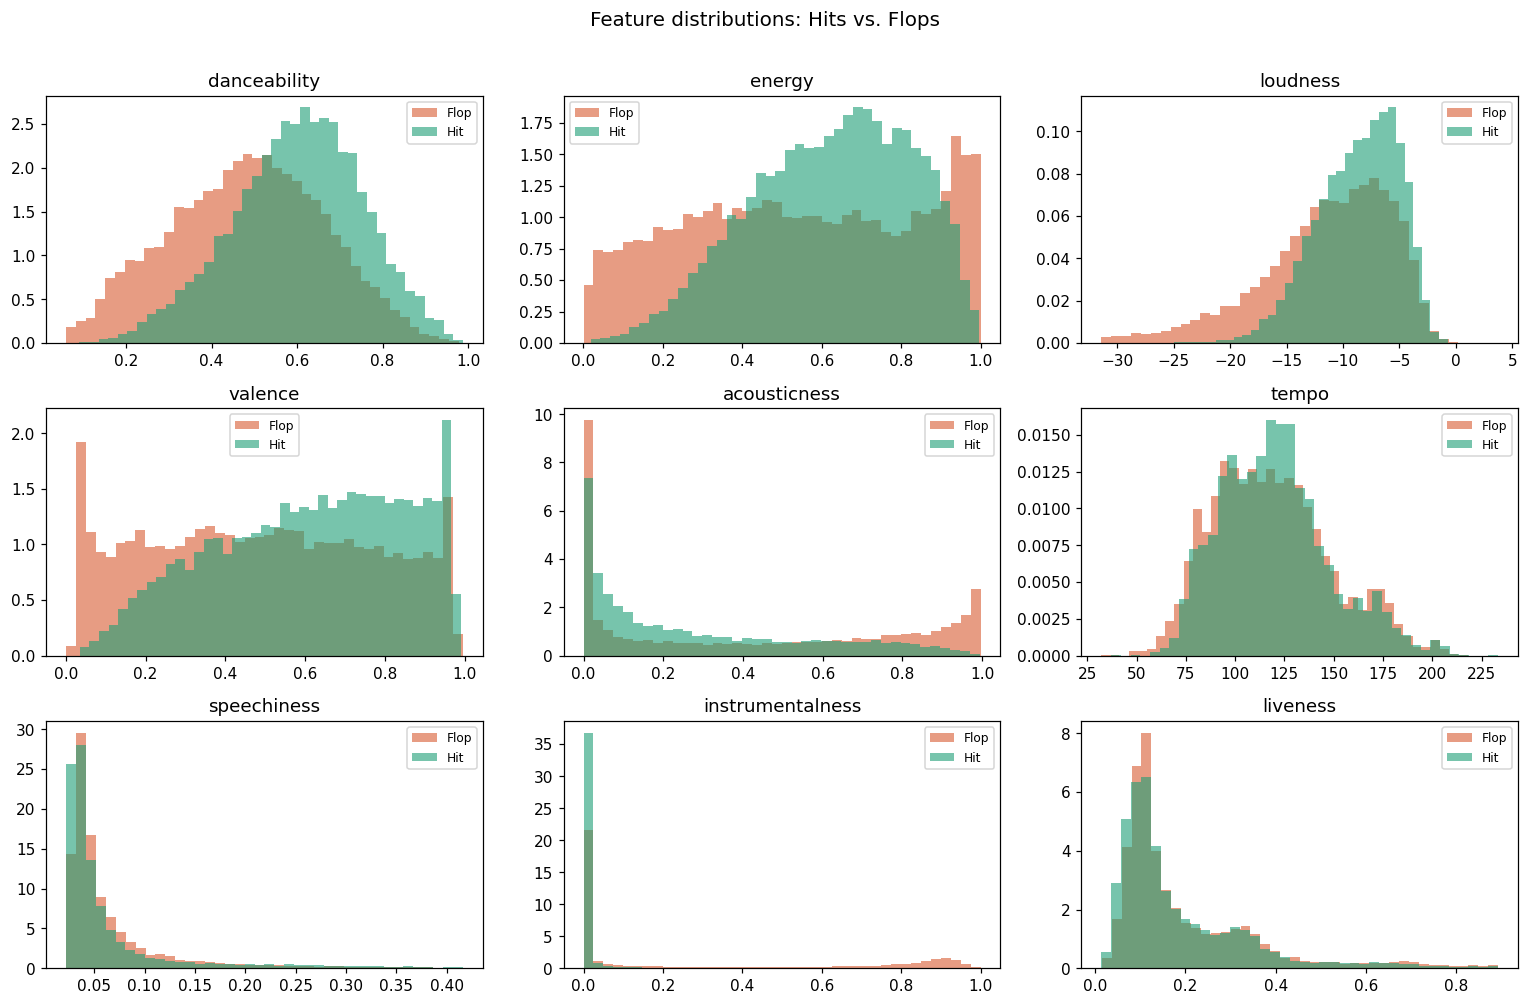

In [14]:
# --- 3.2 Feature distributions: Hits vs. Flops ---
audio_features = ['danceability', 'energy', 'loudness', 'valence',
                  'acousticness', 'tempo', 'speechiness', 'instrumentalness', 'liveness']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    axes[i].hist(df[df['target']==0][feat], bins=40, alpha=0.6, color='#d85a30', label='Flop', density=True)
    axes[i].hist(df[df['target']==1][feat], bins=40, alpha=0.6, color='#1d9e75', label='Hit',  density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature distributions: Hits vs. Flops', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

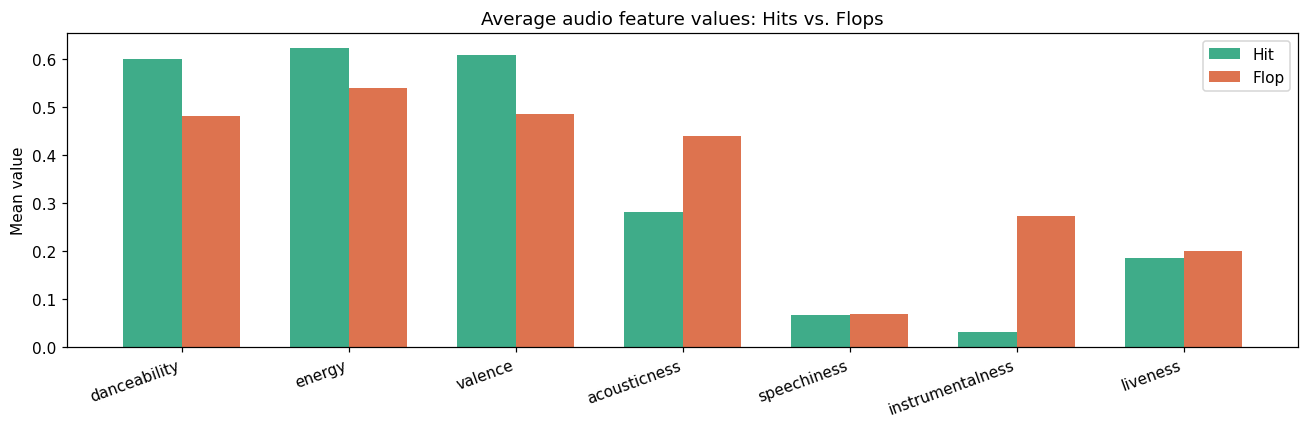

In [15]:
# --- 3.3 Average feature values: Hits vs. Flops ---
bounded = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness', 'liveness']
means_hit  = df[df['target']==1][bounded].mean()
means_flop = df[df['target']==0][bounded].mean()

x = np.arange(len(bounded))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, means_hit,  w, label='Hit',  color='#1d9e75', alpha=0.85)
ax.bar(x + w/2, means_flop, w, label='Flop', color='#d85a30', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bounded, rotation=20, ha='right')
ax.set_ylabel('Mean value')
ax.set_title('Average audio feature values: Hits vs. Flops')
ax.legend()
plt.tight_layout()
plt.show()

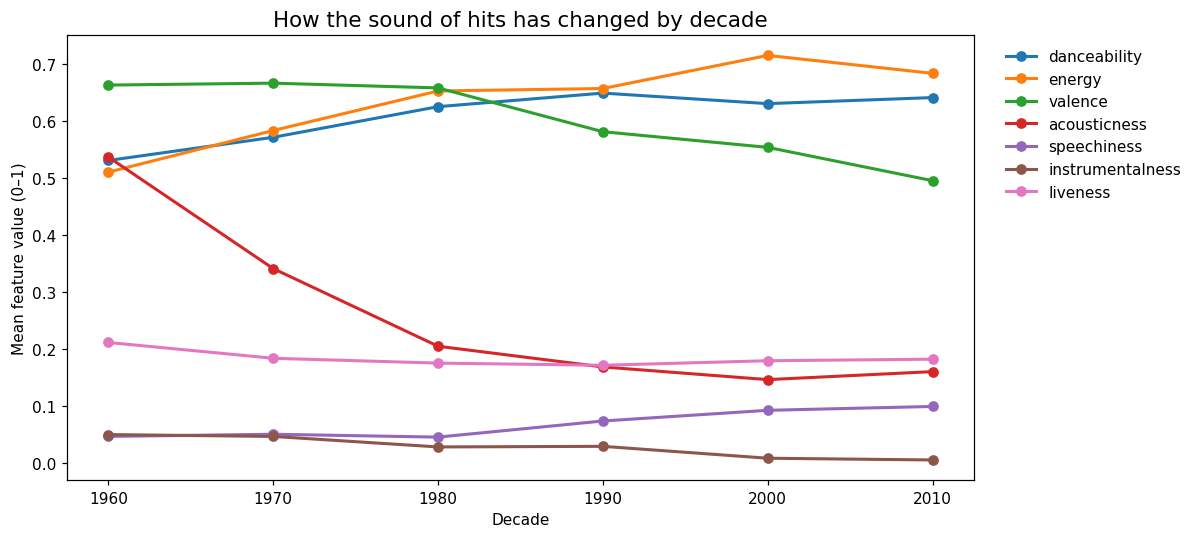

In [16]:
# --- 3.4 How has the sound of hits changed by decade? ---
hit_df = df[df['target'] == 1]
decade_trends = hit_df.groupby('decade')[['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness', 'liveness']].mean()

fig, ax = plt.subplots(figsize=(11, 5))

for col in decade_trends.columns:
    ax.plot(
        decade_trends.index,
        decade_trends[col],
        marker='o',
        label=col,
        linewidth=2
    )

ax.set_title('How the sound of hits has changed by decade', fontsize=14)
ax.set_xlabel('Decade')
ax.set_ylabel('Mean feature value (0–1)')

ax.set_xticks(decade_trends.index)

# Legend outside
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    ncol=1
)

plt.tight_layout()
plt.show()

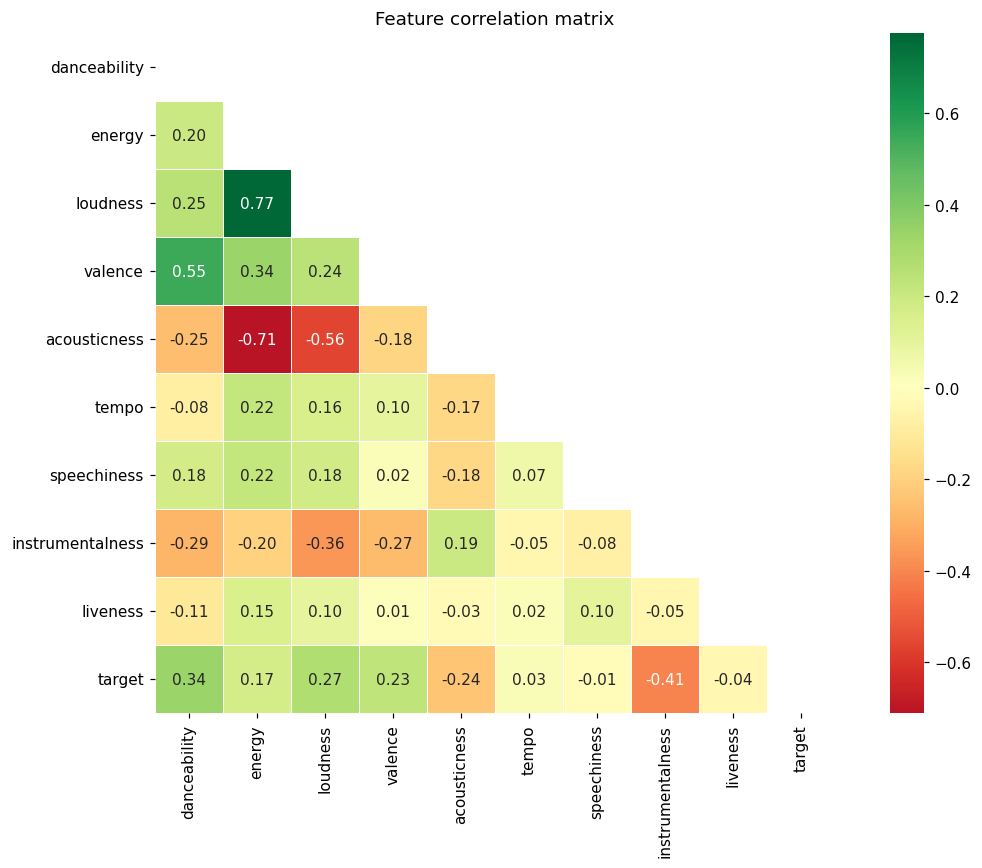

In [17]:
# --- 3.5 Correlation matrix ---
fig, ax = plt.subplots(figsize=(11, 8))
corr = df[audio_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

---

## 4. Clustering
We use K-Means clustering to see if there are natural "types" of songs in the data — for example, energetic dance tracks vs. quiet acoustic songs. We then check how hit rates vary across these clusters.

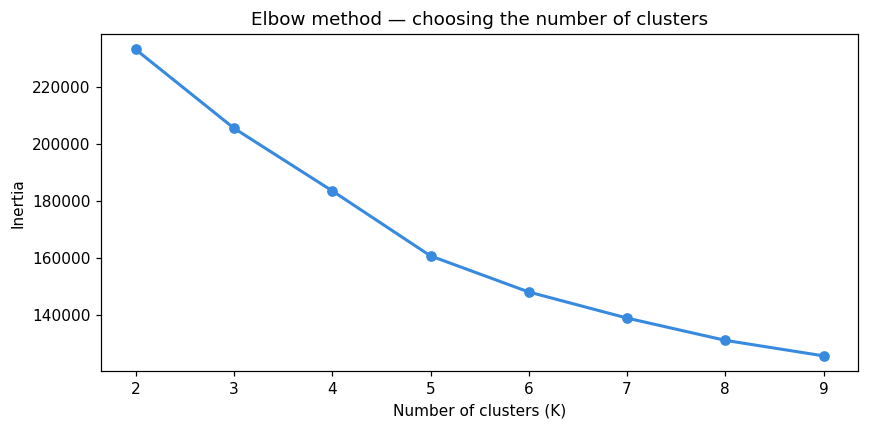

In [18]:
# Features for clustering
cluster_features = ['danceability', 'energy', 'valence', 'acousticness',
                    'tempo', 'loudness', 'speechiness', 'instrumentalness']

cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_features])

# Elbow method to pick K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, marker='o', color='#378add', linewidth=2)
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method — choosing the number of clusters')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import sklearn

sklearn.set_config(working_memory=4096)  # MB 단위

X_cluster32 = X_cluster.astype(np.float32)

sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster32)

    score = silhouette_score(
        X_cluster32,
        labels,
        metric='euclidean'
    )

    sil_scores.append(score)
    print(f'K={k} | Silhouette Score = {score:.4f}')

K=2 | Silhouette Score = 0.2656
K=3 | Silhouette Score = 0.1907
K=4 | Silhouette Score = 0.2101
K=5 | Silhouette Score = 0.2039
K=6 | Silhouette Score = 0.2033
K=7 | Silhouette Score = 0.1877
K=8 | Silhouette Score = 0.1737
K=9 | Silhouette Score = 0.1724


Although K=2 produced the highest Silhouette Score, the clusters were overly broad and less interpretable.

We selected K=5 because it provided more meaningful and distinguishable music profiles while still maintaining reasonable clustering quality.

In [20]:
# Fit with chosen K (adjust based on the elbow above)
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
0     4377
1    20551
2    11031
3     3172
Name: cluster, dtype: int64


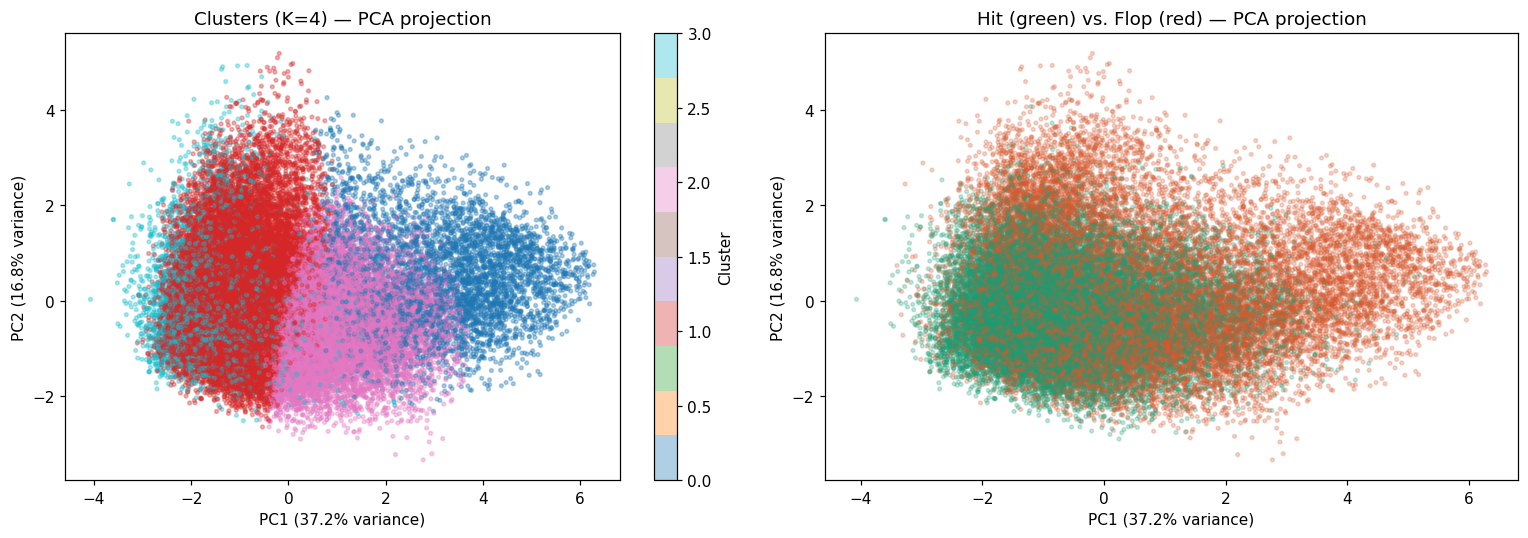

In [21]:
# Visualise clusters with PCA (reduce to 2D for plotting)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.35, s=6)
axes[0].set_title(f'Clusters (K={K_OPTIMAL}) — PCA projection')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(sc, ax=axes[0], label='Cluster')

colors = ['#d85a30' if t == 0 else '#1d9e75' for t in df['target']]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.25, s=6)
axes[1].set_title('Hit (green) vs. Flop (red) — PCA projection')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()
plt.show()

In [22]:
# Cluster profiles — what does each cluster represent?
profile = df.groupby('cluster')[cluster_features + ['target']].mean().round(3)
profile.rename(columns={'target': 'hit_rate'}, inplace=True)
profile['size'] = df['cluster'].value_counts().sort_index()
print(profile)

         danceability  energy  valence  acousticness    tempo  loudness  \
cluster                                                                   
0               0.368   0.264    0.279         0.755  109.179   -17.872   
1               0.581   0.743    0.635         0.153  125.220    -7.592   
2               0.510   0.378    0.492         0.632  112.803   -12.169   
3               0.662   0.703    0.570         0.198  120.690    -7.391   

         speechiness  instrumentalness  hit_rate   size  
cluster                                                  
0              0.046             0.740     0.043   4377  
1              0.056             0.103     0.606  20551  
2              0.043             0.028     0.502  11031  
3              0.247             0.051     0.591   3172  


In [23]:
# Cluster feature means
profile = df.groupby('cluster')[cluster_features].mean()

# Standardize across clusters
profile_z = (
    profile - profile.mean()
) / profile.std()

print(profile_z.round(2))

         danceability  energy  valence  acousticness  tempo  loudness  \
cluster                                                                 
0               -1.30   -1.09    -1.39          1.06  -1.07     -1.34   
1                0.40    0.93     0.91         -0.93   1.13      0.74   
2               -0.16   -0.61    -0.01          0.65  -0.57     -0.19   
3                1.06    0.76     0.49         -0.78   0.51      0.78   

         speechiness  instrumentalness  
cluster                                 
0              -0.52              1.49  
1              -0.43             -0.37  
2              -0.55             -0.59  
3               1.50             -0.53  


In [24]:
# Z-score standardization
profile_z = ((profile - profile.mean()) / profile.std()).round(2)

# Show top 2 features for each cluster
for cluster in profile_z.index:
    print(f'\n===== Cluster {cluster} =====')

    top_features = profile_z.loc[cluster].sort_values(ascending=False)

    print(top_features.head(2))


===== Cluster 0 =====
instrumentalness    1.49
acousticness        1.06
Name: 0, dtype: float64

===== Cluster 1 =====
tempo     1.13
energy    0.93
Name: 1, dtype: float64

===== Cluster 2 =====
acousticness    0.65
valence        -0.01
Name: 2, dtype: float64

===== Cluster 3 =====
speechiness     1.50
danceability    1.06
Name: 3, dtype: float64


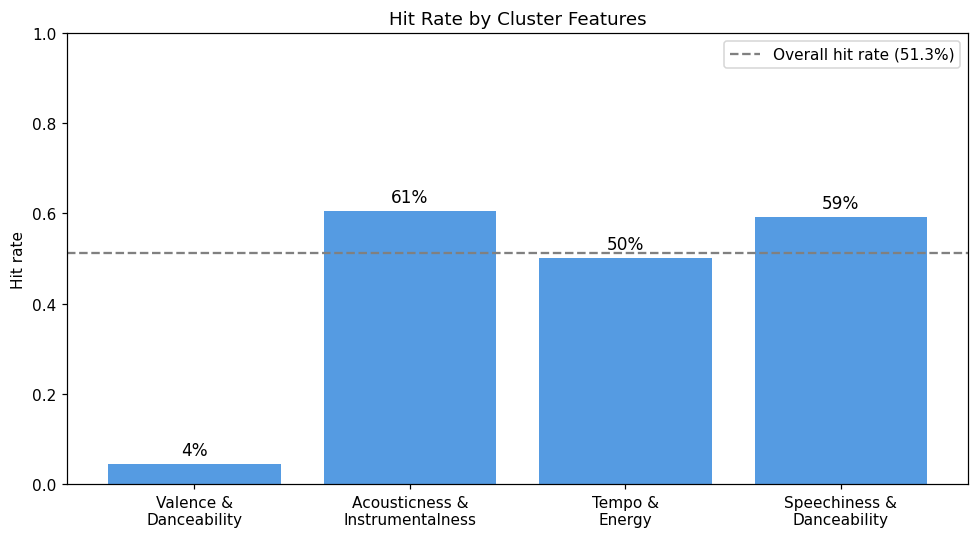

In [25]:
# Cluster feature labels
cluster_labels = {
    0: 'Valence &\nDanceability',
    1: 'Acousticness &\nInstrumentalness',
    2: 'Tempo &\nEnergy',
    3: 'Speechiness &\nDanceability'
}

# Hit rate by cluster
hit_rates = df.groupby('cluster')['target'].mean()

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    [cluster_labels[i] for i in hit_rates.index],
    hit_rates.values,
    color='#378add',
    alpha=0.85
)

# Overall average line
ax.axhline(
    df['target'].mean(),
    linestyle='--',
    color='gray',
    label=f'Overall hit rate ({df["target"].mean():.1%})'
)

ax.set_ylabel('Hit rate')
ax.set_title('Hit Rate by Cluster Features')
ax.set_ylim(0, 1)

ax.legend()

# Percentage labels
for i, rate in enumerate(hit_rates.values):
    ax.text(
        i,
        rate + 0.02,
        f'{rate:.0%}',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [26]:
# Remove cluster column before modelling
df_model = df.drop(columns=['cluster'])
FEATURES = [c for c in df_model.columns if c != 'target']
X = df_model[FEATURES]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 31,304 | Test: 7,827


# 5. Modeling & Hyperparameter Tuning
## We train three models — going from simple to complex:

1. Logistic Regression — simple, interpretable baseline
2. Random Forest — ensemble of decision trees
3. Gradient Boosted Trees — sequential boosting, usually the strongest

In [27]:
# We'll store results here for comparison at the end
results = {}

## 5.1 Logistic Regression

In [28]:
# Tune regularization strength C and penalty type (L1 vs L2)
lr_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=lr_grid, scoring='roc_auc', cv=5, n_jobs=-1
)
lr_cv.fit(X_train_sc, y_train)

print('Best params:', lr_cv.best_params_)
print('Best CV AUC:', round(lr_cv.best_score_, 4))

Best params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC: 0.8052


In [29]:
best_lr = lr_cv.best_estimator_
y_pred_lr  = best_lr.predict(X_test_sc)
y_proba_lr = best_lr.predict_proba(X_test_sc)[:, 1]

results['Logistic Regression'] = {
    'auc': roc_auc_score(y_test, y_proba_lr),
    'acc': accuracy_score(y_test, y_pred_lr),
    'f1':  f1_score(y_test, y_pred_lr),
    'y_pred': y_pred_lr, 'y_proba': y_proba_lr
}
print(f"Test AUC: {results['Logistic Regression']['auc']:.4f}")
print(f"Test Accuracy: {results['Logistic Regression']['acc']:.4f}")

Test AUC: 0.8044
Test Accuracy: 0.7334


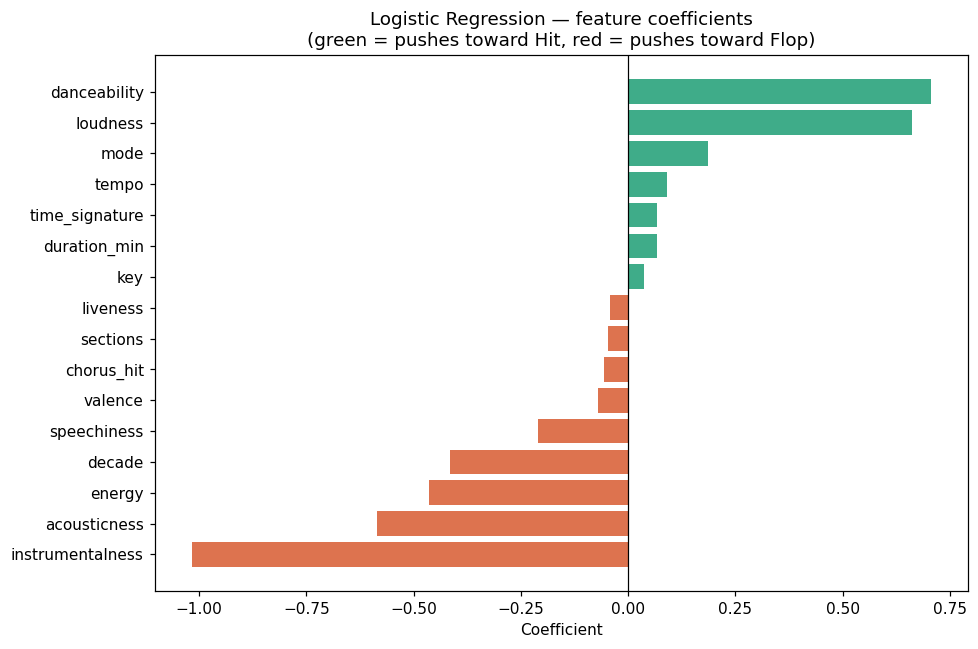

In [30]:
# Which features push a song toward being a hit?
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': best_lr.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1d9e75' if c > 0 else '#d85a30' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — feature coefficients\n(green = pushes toward Hit, red = pushes toward Flop)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

## 5.2 Random Forest

In [31]:
from scipy.stats import randint

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5]
}
rf_cv = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_params, n_iter=15,
    scoring='roc_auc', cv=5, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rf_cv.fit(X_train, y_train)

print('Best params:', rf_cv.best_params_)
print('Best CV AUC:', round(rf_cv.best_score_, 4))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV AUC: 0.8773


In [32]:
best_rf = rf_cv.best_estimator_
y_pred_rf  = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'auc': roc_auc_score(y_test, y_proba_rf),
    'acc': accuracy_score(y_test, y_pred_rf),
    'f1':  f1_score(y_test, y_pred_rf),
    'y_pred': y_pred_rf, 'y_proba': y_proba_rf
}
print(f"Test AUC: {results['Random Forest']['auc']:.4f}")
print(f"Test Accuracy: {results['Random Forest']['acc']:.4f}")

Test AUC: 0.8792
Test Accuracy: 0.8018


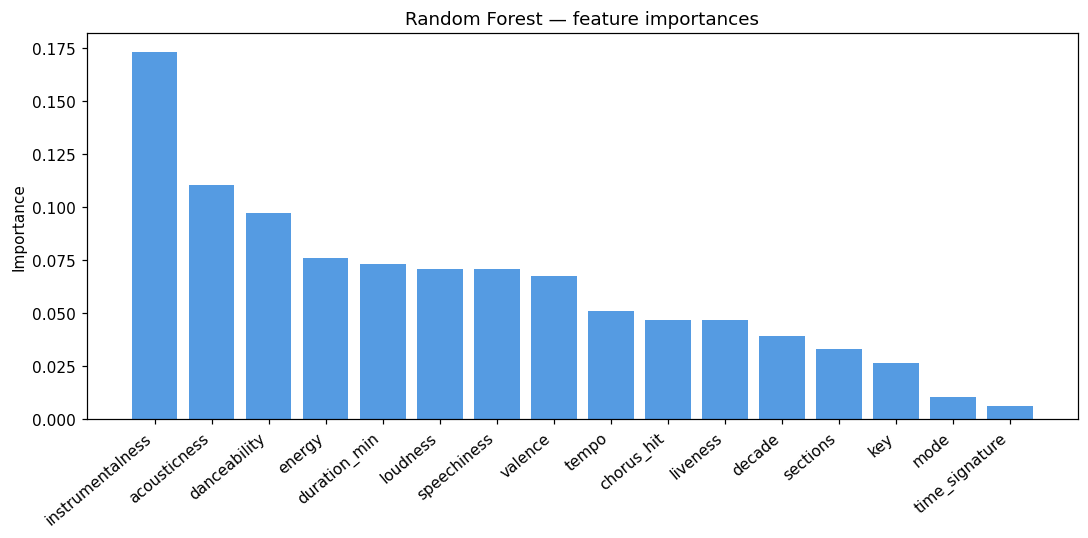

In [33]:
# Feature importances
importances = best_rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(FEATURES)), importances[idx], color='#378add', alpha=0.85)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(np.array(FEATURES)[idx], rotation=40, ha='right')
ax.set_title('Random Forest — feature importances')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

## 5.3 Gradient Boosted Trees

In [34]:
from scipy.stats import uniform

gbt_params = {
    'n_estimators':     randint(100, 400),
    'learning_rate':    uniform(0.01, 0.2),
    'max_depth':        randint(2, 7),
    'subsample':        uniform(0.6, 0.4),
    'min_samples_leaf': randint(1, 20)
}
gbt_cv = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gbt_params, n_iter=20,
    scoring='roc_auc', cv=5, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
gbt_cv.fit(X_train, y_train)

print('Best params:', gbt_cv.best_params_)
print('Best CV AUC:', round(gbt_cv.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'learning_rate': 0.0849080237694725, 'max_depth': 6, 'min_samples_leaf': 15, 'n_estimators': 206, 'subsample': 0.9118764001091078}
Best CV AUC: 0.8837


In [35]:
best_gbt = gbt_cv.best_estimator_
y_pred_gbt  = best_gbt.predict(X_test)
y_proba_gbt = best_gbt.predict_proba(X_test)[:, 1]

results['Gradient Boosted Trees'] = {
    'auc': roc_auc_score(y_test, y_proba_gbt),
    'acc': accuracy_score(y_test, y_pred_gbt),
    'f1':  f1_score(y_test, y_pred_gbt),
    'y_pred': y_pred_gbt, 'y_proba': y_proba_gbt
}
print(f"Test AUC: {results['Gradient Boosted Trees']['auc']:.4f}")
print(f"Test Accuracy: {results['Gradient Boosted Trees']['acc']:.4f}")

Test AUC: 0.8808
Test Accuracy: 0.8045


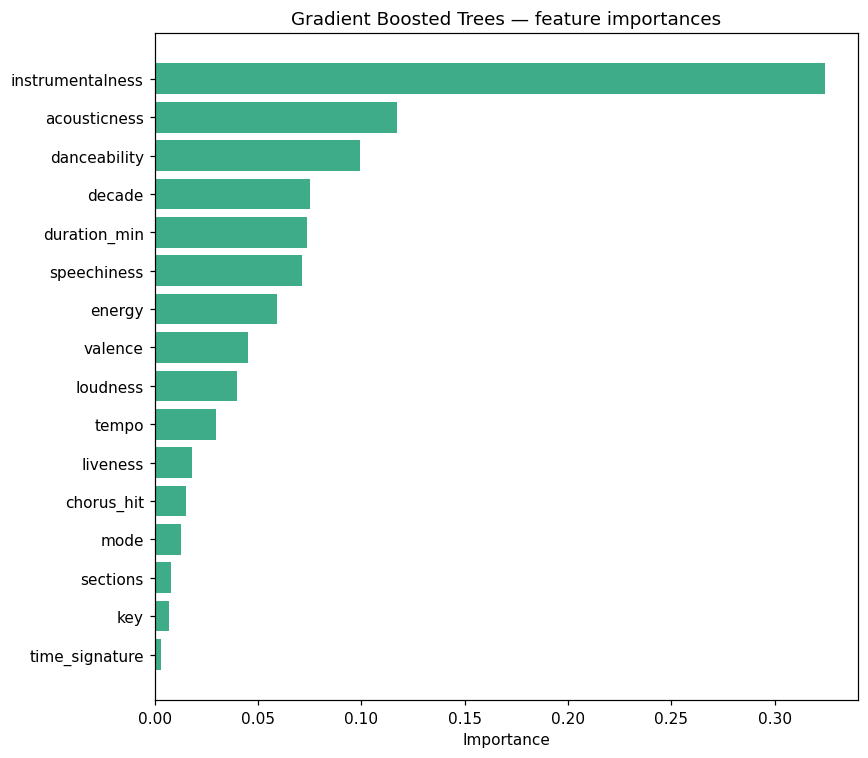

In [36]:
# GBT Feature importances
fi = best_gbt.feature_importances_
sorted_idx = np.argsort(fi)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(np.array(FEATURES)[sorted_idx], fi[sorted_idx], color='#1d9e75', alpha=0.85)
ax.set_title('Gradient Boosted Trees — feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [37]:
# --- 6.1 Summary table ---
summary = pd.DataFrame([
    {'Model': name, 'Test AUC': round(v['auc'], 4), 'Accuracy': round(v['acc'], 4), 'F1': round(v['f1'], 4)}
    for name, v in results.items()
])
print(summary.to_string(index=False))

                 Model  Test AUC  Accuracy     F1
   Logistic Regression    0.8044    0.7334 0.7592
         Random Forest    0.8792    0.8018 0.8172
Gradient Boosted Trees    0.8808    0.8045 0.8196


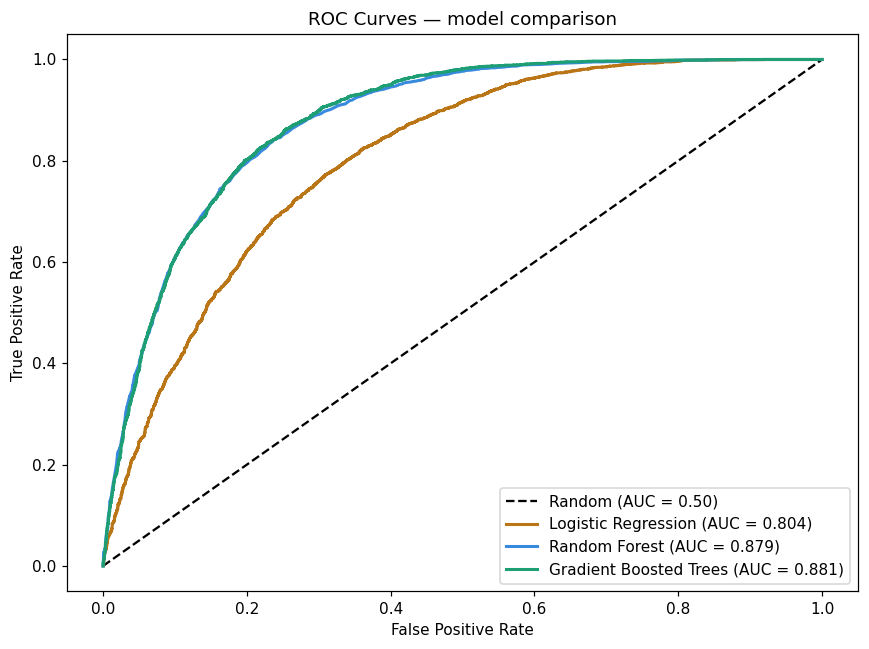

In [38]:
# --- 6.2 ROC curves ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

colors_roc = ['#ba7517', '#378add', '#1d9e75']
for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {v['auc']:.3f})", color=color, linewidth=2)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — model comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

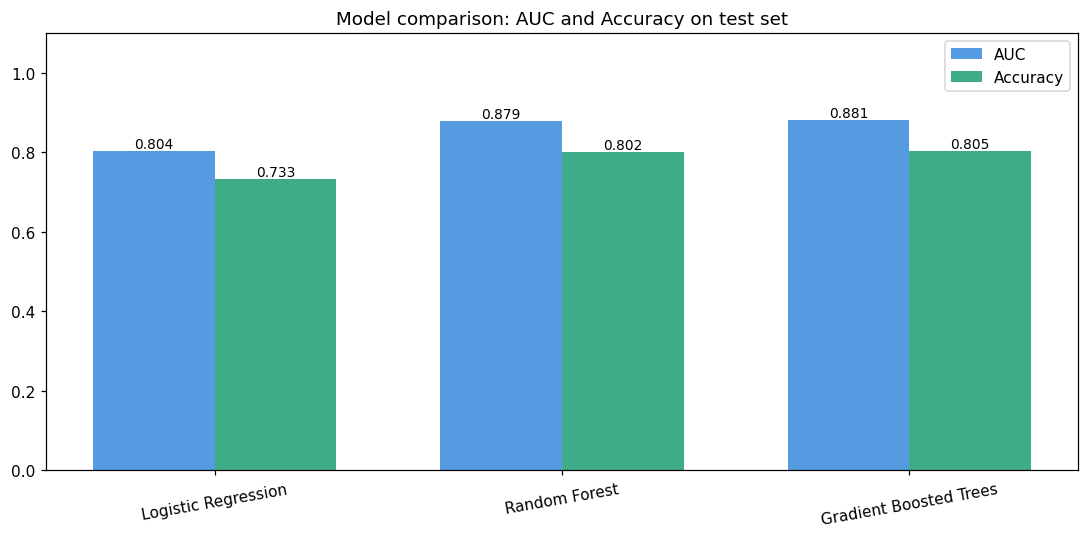

In [39]:
# --- 6.3 Bar chart: AUC and Accuracy ---
model_names = list(results.keys())
aucs = [results[n]['auc'] for n in model_names]
accs = [results[n]['acc'] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, aucs, w, label='AUC',      color='#378add', alpha=0.85)
b2 = ax.bar(x + w/2, accs, w, label='Accuracy', color='#1d9e75', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', fontsize=9)
ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_title('Model comparison: AUC and Accuracy on test set')
ax.legend()
plt.tight_layout()
plt.show()

Best model: Gradient Boosted Trees


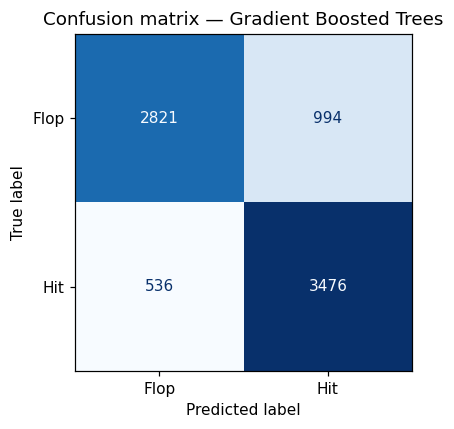

In [40]:
# --- 6.4 Confusion matrix for the best model ---
best_name = max(results, key=lambda n: results[n]['auc'])
print(f'Best model: {best_name}')

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Flop', 'Hit']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

In [46]:
# Print full performance summary
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"AUC      : {metrics['auc']:.4f}")
    print(f"Accuracy : {metrics['acc']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")


Logistic Regression
AUC      : 0.8044
Accuracy : 0.7334
F1 Score : 0.7592

Random Forest
AUC      : 0.8792
Accuracy : 0.8018
F1 Score : 0.8172

Gradient Boosted Trees
AUC      : 0.8808
Accuracy : 0.8045
F1 Score : 0.8196


In [47]:
# --- 6.5 Full classification report for all models ---

for best_name in results.keys():

    print(f'\nClassification report — {best_name}\n')

    print(
        classification_report(
            y_test,
            results[best_name]['y_pred'],
            target_names=['Flop', 'Hit']
        )
    )


Classification report — Logistic Regression

              precision    recall  f1-score   support

        Flop       0.77      0.64      0.70      3815
         Hit       0.71      0.82      0.76      4012

    accuracy                           0.73      7827
   macro avg       0.74      0.73      0.73      7827
weighted avg       0.74      0.73      0.73      7827


Classification report — Random Forest

              precision    recall  f1-score   support

        Flop       0.84      0.74      0.78      3815
         Hit       0.78      0.86      0.82      4012

    accuracy                           0.80      7827
   macro avg       0.81      0.80      0.80      7827
weighted avg       0.81      0.80      0.80      7827


Classification report — Gradient Boosted Trees

              precision    recall  f1-score   support

        Flop       0.84      0.74      0.79      3815
         Hit       0.78      0.87      0.82      4012

    accuracy                           0.80    

## Best Performing Model — Gradient Boosted Trees

Among the three models, **Gradient Boosted Trees achieved the best overall performance**.

| Metric | Score |
|---|---|
| Test AUC | **0.8808** |
| Accuracy | **0.8045** |
| F1 Score | **0.8196** |

This suggests that Gradient Boosted Trees captured complex nonlinear relationships between Spotify audio features and song popularity more effectively than the other models.

The model significantly outperformed Logistic Regression and slightly outperformed Random Forest across all evaluation metrics.

# 7. Summary & Discussion

## What we did

We used the Spotify Hit Predictor dataset (~41,000 tracks from 1960–2019) to predict whether a song would appear on the Billboard Hot-100 based purely on its audio features.

After cleaning the data and performing exploratory data analysis (EDA), we trained and compared three classification models:

- Logistic Regression
- Random Forest
- Gradient Boosted Trees

---

## Key findings from EDA

- **Hit songs tend to be louder, more energetic, and more danceable** than flop songs.
- **The sound of hit songs has changed significantly over time.**
    - 1960s hits were more acoustic.
    - Modern hits are louder and more energetic.
    - Valence ("happiness") generally decreased over the decades.
- **K-Means clustering identified four natural song groups** with different hit rates:
    - Danceable / positive songs
    - Acoustic / instrumental songs
    - Fast & energetic songs
    - Speech-heavy / rap-oriented songs

---

## Model results

| Model | Test AUC | Accuracy |
|---|---|---|
| Logistic Regression | 0.804 | 0.733 |
| Random Forest | 0.879 | 0.802 |
| Gradient Boosted Trees | **0.881** | **0.805** |

The **Gradient Boosted Trees** model achieved the best overall performance.

Across the models, the most influential features were:

- `danceability`
- `loudness`
- `instrumentalness`
- `acousticness`

---

## Limitations

- **No artist information included**
    - Popularity, fanbase, and marketing strongly affect chart success.
- **Billboard reflects US charts only**
    - Some globally popular songs may still be labeled as flops.
- **No lyric/text analysis**
    - Lyrics, sentiment, and language were not considered.
- **Different decades were mixed together**
    - Musical trends change significantly over time.

---

## What could be improved

- Build **decade-specific prediction models**
- Include **artist popularity features**
- Add **lyric-based NLP features**
- Experiment with more advanced models such as:
    - XGBoost
    - LightGBM